Analisi dei fenomeni di bordo per un condesatore a facce piane in quadrato conduttore

In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [25]:
VP = 100
VM = -100

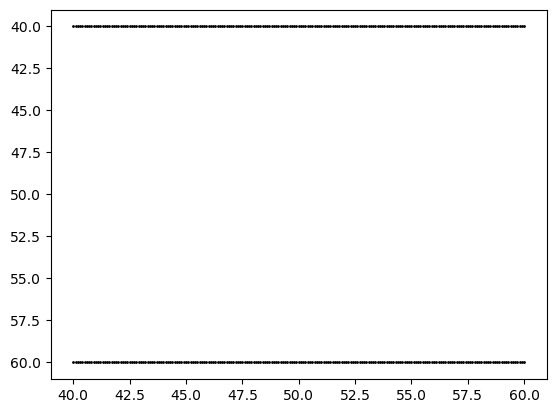

In [26]:

# Fissiamo la distribuzione di carica
NREALE = 100     #   Larghezza scatola (necessariamente intero)
WREALE = 20      #   Larghezza piastra (necessariamente intero)
HREALE = 40      #   altezza in cui mettiamo la piastra superiore da cima e inferiore da fondo rispettivamente

DX = DY = 0.1
N = int(NREALE / DX)
W = int(WREALE / DX)
H = int(HREALE / DX)

V = np.zeros((N,N))
COLONNA = int((N/2) - W/2)

V[H, COLONNA:COLONNA+W+1]       = VP # Volts
V[N-H, COLONNA:COLONNA+W+1]     = VM # Volts


Y, X = np.where(V != 0)

plt.scatter(X*DX, Y*DY, c="black", s=1)
plt.gca().invert_yaxis()
plt.show()



In [ ]:
ITERAZIONI = 20000 # eh si, per forza, andrebbe messa una condizione sulla convergenza 
# ma se ci pensiamo bene meglio non inserire 20000 if in più

def esperimento():
    # Absolute genius!!!
    V[1:-1, 1:-1] = 0.25 * (V[2:, 1:-1] + V[:-2, 1:-1] + 
                             V[1:-1, 2:] + V[1:-1, :-2])
    # La vettorializazzione non è solo un passatempo per Nerds
    # sappiamo tutti che python fa cagare. Però la vettorializaazzione
    # viene gestita in altro modo sotto al cofano

    # Reimposta le piastre ad ogni iterazione 
    V[H, COLONNA:COLONNA+W+1]   = VP
    V[N-H, COLONNA:COLONNA+W+1] = VM

for i in range(ITERAZIONI):
    esperimento()

In [28]:
# Ringraziamo la AI per questo grafico

import plotly.graph_objects as go

step = 5
x = np.arange(V.shape[1]) * DX
y = np.arange(V.shape[0]) * DY
Xs = x[::step]
Ys = y[::step]
Vs = V[::step, ::step]

fig = go.Figure()

# Superficie 3D
fig.add_trace(go.Surface(
    x=Xs, y=Ys, z=Vs,
    colorscale='Viridis',
    opacity=0.8,
    name='Potenziale'
))

fig.update_layout(
    title='Potenziale elettrico',
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='V (Volt)'
    )
)

fig.show()

fig2 = go.Figure(go.Contour(
    x=Xs, y=Ys, z=Vs,
    colorscale='Viridis',
    contours=dict(
        coloring='lines',
        showlabels=True,
        start=V.min(),
        end=V.max(),
        size=10        # intervallo tra le linee
    )
))

fig2.update_layout(
    title='Linee equipotenziali',
    xaxis_title='x (m)',
    yaxis_title='y (m)',
    yaxis=dict(scaleanchor='x')  # aspect ratio uguale
)

fig2.show()
print(V)


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.37382662e-09  2.74953388e-09 ...  2.86483988e-09
   1.43114136e-09  0.00000000e+00]
 [ 0.00000000e+00  2.74931398e-09  5.50356593e-09 ...  5.73314673e-09
   2.86462312e-09  0.00000000e+00]
 ...
 [ 0.00000000e+00 -2.85906313e-09 -5.72204227e-09 ... -5.96202748e-09
  -2.97835303e-09  0.00000000e+00]
 [ 0.00000000e+00 -1.42836940e-09 -2.85930412e-09 ... -2.97859129e-09
  -1.48828188e-09  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
